# EDA Visualisations

## Import Necessary Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from ipywidgets import interact, SelectMultiple, Dropdown, Checkbox

## Load Data

In [8]:
df = pd.read_csv("C:/Users/Fatim/Downloads/final_model_data.csv")

### Set up

In [11]:
# Ensure datetime index
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

# Time features
df['hour'] = df.index.hour
df['month'] = df.index.month
df['year'] = df.index.year
df['dayofyear'] = df.index.dayofyear

# Weather aggregates
temp_cols = [c for c in df.columns if c.startswith('Temp_')]
wind_cols = [c for c in df.columns if c.startswith('Wind10m_')]
solar_cols = [c for c in df.columns if c.startswith('Solar_')]

df['Temp_Mean'] = df[temp_cols].mean(axis=1)
df['Wind_Mean'] = df[wind_cols].mean(axis=1)
df['Solar_Mean'] = df[solar_cols].mean(axis=1)

In [13]:
# Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].apply(get_season)

In [15]:
# view data
df.head()

,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,NET_IMPORTS,...,Temp_Eng_South_Bristol,Solar_Eng_South_Bristol,hour,month,year,dayofyear,Temp_Mean,Wind_Mean,Solar_Mean,season
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,26630.5,27418.5,24107.0,1046.5,6465.0,0.0,13040.0,0.0,16.0,3237.5,...,6.2,0.0,0,1,2020,1,4.285,12.0625,0.0,Winter
2020-01-01 01:00:00,26161.5,26837.5,23717.5,1026.5,6465.0,0.0,13040.0,0.0,16.5,3349.5,...,5.4,0.0,1,1,2020,1,4.215,12.2750,0.0,Winter
2020-01-01 02:00:00,24771.5,25683.0,22500.0,993.0,6465.0,0.0,13040.0,0.0,173.5,3268.5,...,4.2,0.0,2,1,2020,1,4.285,12.1875,0.0,Winter
2020-01-01 03:00:00,23382.5,24899.5,21157.0,965.5,6465.0,0.0,13040.0,0.0,843.0,2665.5,...,4.7,0.0,3,1,2020,1,4.480,12.7375,0.0,Winter
2020-01-01 04:00:00,22429.5,23860.0,20393.0,995.5,6465.0,0.0,13040.0,0.0,711.5,1688.0,...,4.9,0.0,4,1,2020,1,4.635,12.3500,0.0,Winter


## Table 1: Dataset Overview
simple overview of the dataset. Includes number of columns, rows, and range of data.

In [18]:
# Table 1: Dataset Overview
table_1 = pd.DataFrame({
    'Metric': [
        'Number of observations',
        'Start date',
        'End date',
        'Time resolution',
        'Number of variables'
    ],
    'Value': [
        df.shape[0],
        df.index.min().date(),
        df.index.max().date(),
        '60 minutes',
        df.shape[1]
    ]
})

table_1


,Metric,Value
0,Number of observations,52608
1,Start date,2020-01-01
2,End date,2025-12-31
3,Time resolution,60 minutes
4,Number of variables,55


## Table 2: Summary statistics for key variables
Simple descriptive statistics for key variables. Includes mean, standard deviation, minimum, median, maximum, and interquartiles.

In [21]:
key_vars = [
    'TSD',
    'ND',
    'EMBEDDED_WIND_GENERATION',
    'EMBEDDED_SOLAR_GENERATION',
    'Temp_Mean',
    'Wind_Mean',
    'Solar_Mean'
]

table_2 = df[key_vars].describe().T[
    ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
]

table_2


,mean,std,min,25%,50%,75%,max
TSD,28737.705686,5919.255561,15510.5000,24247.000,27808.500,32379.75000,47654.5000
ND,26770.351914,6204.036984,12955.0000,21913.500,25880.000,30692.62500,46419.0000
EMBEDDED_WIND_GENERATION,1887.057073,1212.467655,126.5000,912.000,1556.500,2624.50000,5941.0000
EMBEDDED_SOLAR_GENERATION,1578.623242,2476.383781,0.0000,0.000,22.500,2520.62500,13951.0000
Temp_Mean,10.287962,5.334836,-5.1150,6.380,10.125,14.17000,31.8050
Wind_Mean,14.867943,6.240514,2.3125,10.075,13.700,18.62500,46.3375
Solar_Mean,130.641278,193.365770,0.0000,0.000,7.250,214.78125,876.3750


## Figure 1: National Demand (and Transmission System Demand) Over Time
An interactive figure that shows National Demand (ND) and optionally Transmission System Demand (TSD) Over Time.
Can select for year, aggregation type (weekly. monthly, seasonally), TSD, and overlap.

In [29]:
# Ensure datetime index
if not pd.api.types.is_datetime64_any_dtype(df.index):
    df.index = pd.to_datetime(df.index)

def get_agg_series(year, agg_type):
    df_y = df.loc[str(year)].copy()
    
    if agg_type == 'Weekly':
        return df_y['ND'].resample('W').mean(), df_y['TSD'].resample('W').mean()
    elif agg_type == 'Monthly':
        return df_y['ND'].resample('M').mean(), df_y['TSD'].resample('M').mean()
    elif agg_type == 'Seasonal':
        df_y['Season'] = df_y.index.month.map(
            lambda m: 'Winter' if m in [12,1,2] else
                      'Spring' if m in [3,4,5] else
                      'Summer' if m in [6,7,8] else 'Autumn'
        )
        seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
        nd_s = df_y.groupby('Season')['ND'].mean().reindex(seasons)
        tsd_s = df_y.groupby('Season')['TSD'].mean().reindex(seasons)
        return nd_s, tsd_s
    raise ValueError("agg_type must be Weekly, Monthly or Seasonal")

def plot_nd_interactive(
    years       = ['2020', '2021'],
    agg_type    = 'Weekly',
    show_tsd    = True,
    align_years = True
):
    fig = go.Figure()
    
    # Dynamic title
    title = f'{agg_type} Average National Demand (ND)'
    if show_tsd:
        title = f'{agg_type} Average ND vs TSD'
    
    for year in years:
        nd_ser, tsd_ser = get_agg_series(year, agg_type)
        
        if align_years:
            if agg_type == 'Weekly':
                # Week-of-year alignment
                nd_df = nd_ser.reset_index()
                dt_col = nd_df.columns[0]  # safe column name (usually 'index' or 'datetime')
                nd_df['week'] = nd_df[dt_col].dt.isocalendar().week
                nd_agg = nd_df.groupby('week')['ND'].mean().sort_index()
                
                if show_tsd:
                    tsd_df = tsd_ser.reset_index()
                    dt_col_tsd = tsd_df.columns[0]
                    tsd_df['week'] = tsd_df[dt_col_tsd].dt.isocalendar().week
                    tsd_agg = tsd_df.groupby('week')['TSD'].mean().sort_index()
                
                x_nd = nd_agg.index
                y_nd = nd_agg
                x_tsd = tsd_agg.index if show_tsd else None
                y_tsd = tsd_agg if show_tsd else None
                
            elif agg_type == 'Monthly':
                # Date-based alignment
                nd_ser.index = nd_ser.index.map(lambda d: d.replace(year=2000))
                if show_tsd:
                    tsd_ser.index = tsd_ser.index.map(lambda d: d.replace(year=2000))
                x_nd = nd_ser.index
                y_nd = nd_ser
                x_tsd = tsd_ser.index if show_tsd else None
                y_tsd = tsd_ser if show_tsd else None
            else:
                # Seasonal: no alignment needed
                x_nd = nd_ser.index
                y_nd = nd_ser
                x_tsd = tsd_ser.index if show_tsd else None
                y_tsd = tsd_ser if show_tsd else None
        else:
            # No alignment → original dates / categories
            x_nd = nd_ser.index
            y_nd = nd_ser
            x_tsd = tsd_ser.index if show_tsd else None
            y_tsd = tsd_ser if show_tsd else None
        
        # Plot ND
        fig.add_trace(go.Scatter(
            x=x_nd,
            y=y_nd,
            mode='lines+markers',
            name=f'ND {year}',
            line=dict(width=2.3),
            marker=dict(size=6 if agg_type == 'Seasonal' else 4),
            connectgaps=False
        ))
        
        if show_tsd:
            fig.add_trace(go.Scatter(
                x=x_tsd,
                y=y_tsd,
                mode='lines+markers',
                name=f'TSD {year}',
                line=dict(width=2.3, dash='dash'),
                marker=dict(size=6 if agg_type == 'Seasonal' else 4),
                connectgaps=False
            ))
    
    # X-axis setup
    if align_years:
        if agg_type == 'Weekly':
            month_starts = [1, 5, 9, 14, 18, 23, 27, 31, 36, 40, 44, 49]
            month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
            fig.update_xaxes(
                tickmode='array',
                tickvals=month_starts,
                ticktext=month_names,
                title='Month (aligned across years)',
                tickangle=-45
            )
        elif agg_type == 'Monthly':
            month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
            tickvals = pd.date_range('2000-01-15', periods=12, freq='MS')
            fig.update_xaxes(
                tickmode='array',
                tickvals=tickvals,
                ticktext=month_names,
                tickangle=-45,
                title='Month (aligned across years)'
            )
        elif agg_type == 'Seasonal':
            fig.update_xaxes(
                categoryorder='array',
                categoryarray=['Winter','Spring','Summer','Autumn'],
                title='Season'
            )
    else:
        fig.update_xaxes(title='Date' if agg_type in ['Weekly','Monthly'] else 'Season')
    
    fig.update_layout(
        title=title,
        yaxis_title='Demand (MW)',
        hovermode='x unified',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
        height=580,
        template='plotly_white',
        showlegend=True
    )
    
    fig.show()

# Controls
years_available = sorted(df['year'].unique().astype(str).tolist())

interact(
    plot_nd_interactive,
    years=SelectMultiple(options=years_available, value=['2020', '2021'], description='Years:', rows=6),
    agg_type=Dropdown(options=['Weekly', 'Monthly', 'Seasonal'], value='Weekly', description='Time Interval:'),
    show_tsd=Checkbox(value=False, description='Show TSD lines'),
    align_years=Checkbox(value=True, description='Align years (monthly pattern)')
)

interactive(children=(SelectMultiple(description='Years:', index=(0, 1), options=('2020', '2021', '2022', '202…

<function __main__.plot_nd_interactive(years=['2020', '2021'], agg_type='Weekly', show_tsd=True, align_years=True)>

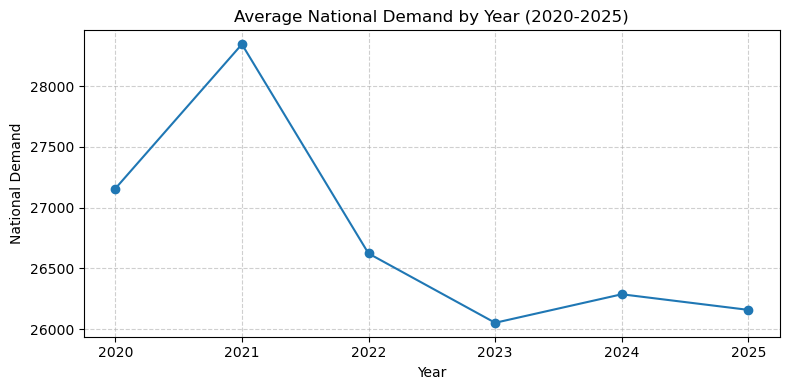

In [69]:
# zoom out
plt.figure(figsize=(8,4))
df.groupby('year')['ND'].mean().plot(marker='o')
plt.title('Average National Demand by Year (2020-2025)')
plt.xlabel('Year')
plt.ylabel('National Demand')
plt.grid(ls='--', alpha=0.6)
plt.tight_layout()
plt.show()

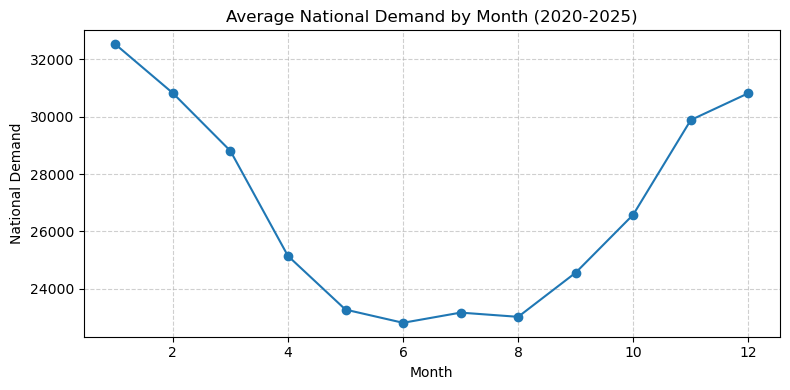

In [71]:
plt.figure(figsize=(8,4))
df.groupby('month')['ND'].mean().plot(marker='o')
plt.title('Average National Demand by Month (2020-2025)')
plt.xlabel('Month')
plt.ylabel('National Demand')
plt.grid(ls='--', alpha=0.6)
plt.tight_layout()
plt.show()

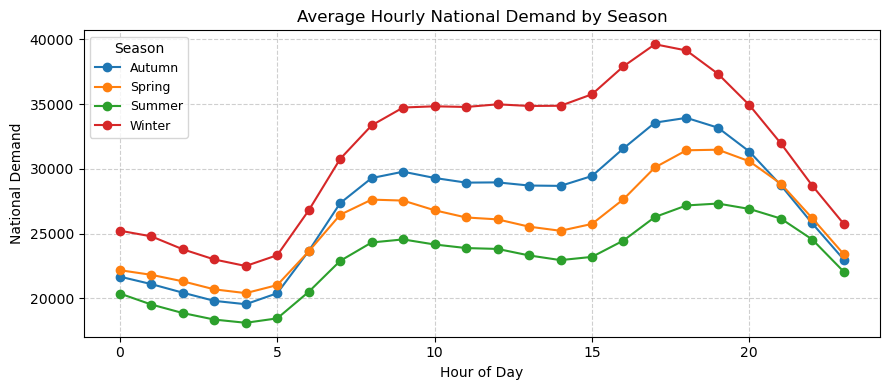

In [79]:
# zoom in
plt.figure(figsize=(9,4))

seasonal_profile = (
    df
    .groupby(['season', 'hour'])['ND']
    .mean()
    .unstack('season')
)

seasonal_profile.plot(
    ax=plt.gca(),
    marker='o'
)

plt.title('Average Hourly National Demand by Season')
plt.xlabel('Hour of Day')
plt.ylabel('National Demand')
plt.grid(ls='--', alpha=0.6)
plt.legend(title='Season', fontsize=9)
plt.tight_layout()
plt.show()


In [1]:
# zoom in
plt.figure(figsize=(9,4))

seasonal_profile = (
    df
    .groupby(['season', 'hour'])['ND']
    .mean()
    .unstack('season')
)

seasonal_profile.plot(
    ax=plt.gca(),
    marker='o'
)

plt.title('Average Hourly National Demand by Season')
plt.xlabel('Hour of Day')
plt.ylabel('National Demand')
plt.grid(ls='--', alpha=0.6)
plt.legend(title='Season', fontsize=9)
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

## Figure 2: Correlation between National Demand and Mean Temperature

Correlation (National Demand vs. Temperature): -0.3801


C:\Users\Fatim\AppData\Local\Temp\ipykernel_19824\1437786648.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



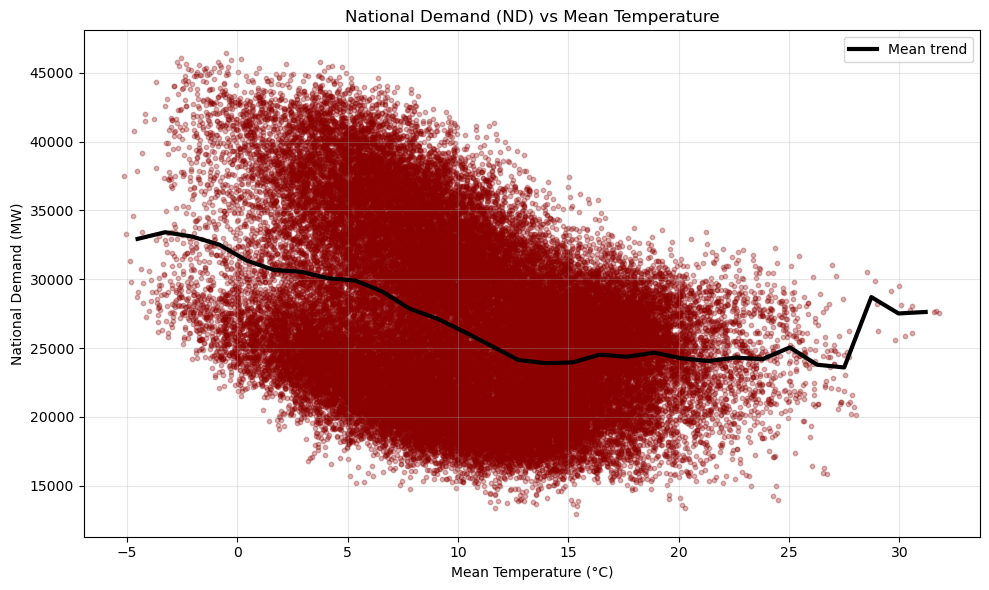

In [32]:
plt.figure(figsize=(10, 6))

corr = df['ND'].corr(df['Temp_Mean'])
print(f"Correlation (National Demand vs. Temperature): {corr:.4f}")

# Scatter with month coloring
scatter = plt.scatter(df['Temp_Mean'], df['ND'], alpha=0.3, s=10, color='darkred')

# Binned mean trend
temp_bins = pd.cut(df['Temp_Mean'], bins=30)
binned_mean = df.groupby(temp_bins)['ND'].mean()
plt.plot(binned_mean.index.categories.mid, binned_mean.values,
         color='black', linewidth=3, label='Mean trend')

plt.title('National Demand (ND) vs Mean Temperature')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('National Demand (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Figure 3: Correlation between Embedded Solar Generation and Mean Solar Radiation

Correlation (Embedded Solar vs Mean Solar Radiation): 0.9518


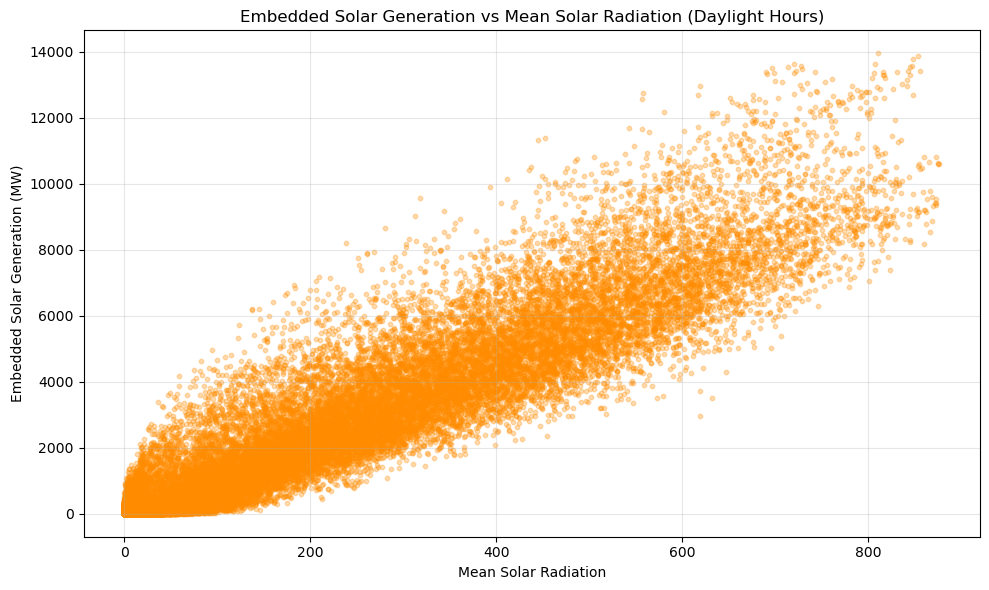

In [34]:
# Mean solar radiation

corr = df['EMBEDDED_SOLAR_GENERATION'].corr(df['Solar_Mean'])
print(f"Correlation (Embedded Solar vs Mean Solar Radiation): {corr:.4f}")

# Daylight hours only
df_day = df[df['hour'].between(6, 18)]

plt.figure(figsize=(10, 6))
plt.scatter(df_day['Solar_Mean'], df_day['EMBEDDED_SOLAR_GENERATION'],
            alpha=0.3, s=10, color='darkorange')
plt.title('Embedded Solar Generation vs Mean Solar Radiation (Daylight Hours)')
plt.xlabel('Mean Solar Radiation')
plt.ylabel('Embedded Solar Generation (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Figure 4: Correlation between Embedded Wind Generation and Mean Wind Speed

Correlation (Embedded Wind vs Mean Wind Speed): 0.9446


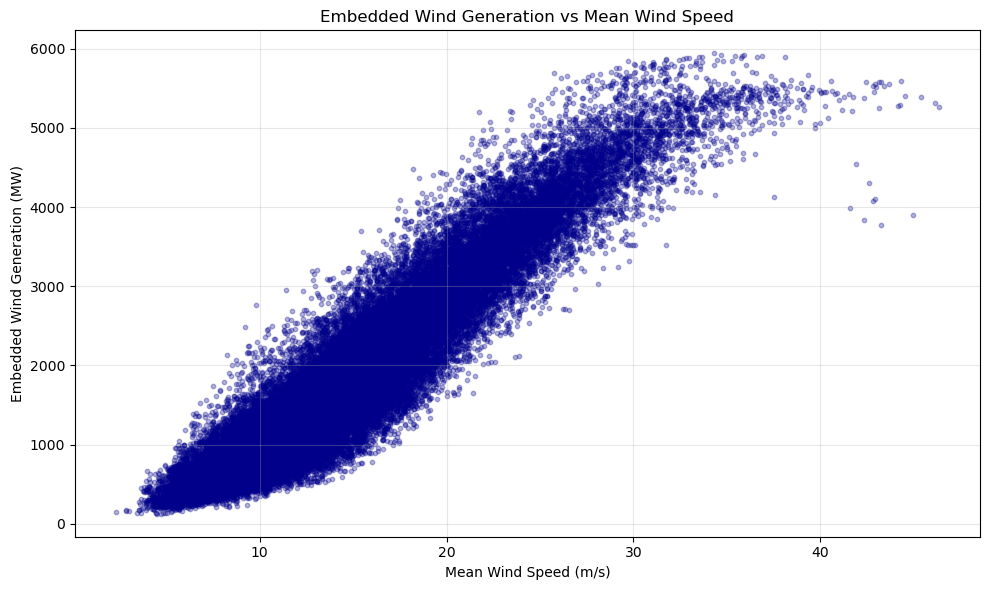

In [38]:
corr_wind = df['EMBEDDED_WIND_GENERATION'].corr(df['Wind_Mean'])
print(f"Correlation (Embedded Wind vs Mean Wind Speed): {corr_wind:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(df['Wind_Mean'], df['EMBEDDED_WIND_GENERATION'],
            alpha=0.3, s=10, color='darkblue')
plt.title('Embedded Wind Generation vs Mean Wind Speed')
plt.xlabel('Mean Wind Speed (m/s)')
plt.ylabel('Embedded Wind Generation (MW)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

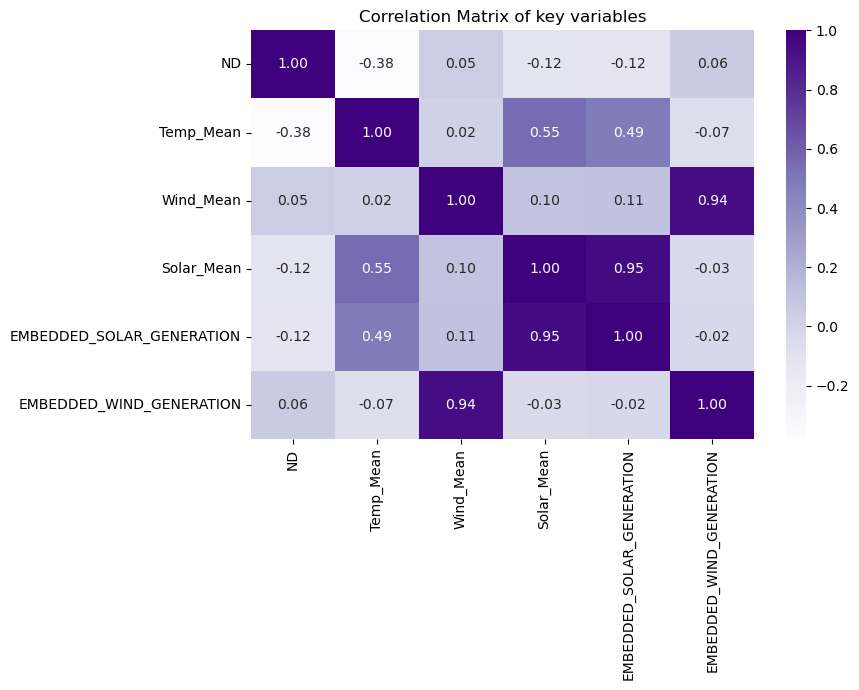

In [40]:
heatmap_vars = [
    'ND',
    'Temp_Mean',
    'Wind_Mean',
    'Solar_Mean',
    'EMBEDDED_SOLAR_GENERATION',
    'EMBEDDED_WIND_GENERATION'
]

plt.figure(figsize=(9,7))
sns.heatmap(
    df[heatmap_vars].corr(),
    annot=True,
    fmt='.2f',
    cmap='Purples'
)
plt.title('Correlation Matrix of key variables')
plt.tight_layout()
plt.show()


## Figure 5 (6): Distribution of Key Variables using Box Plots (Violin Plots)

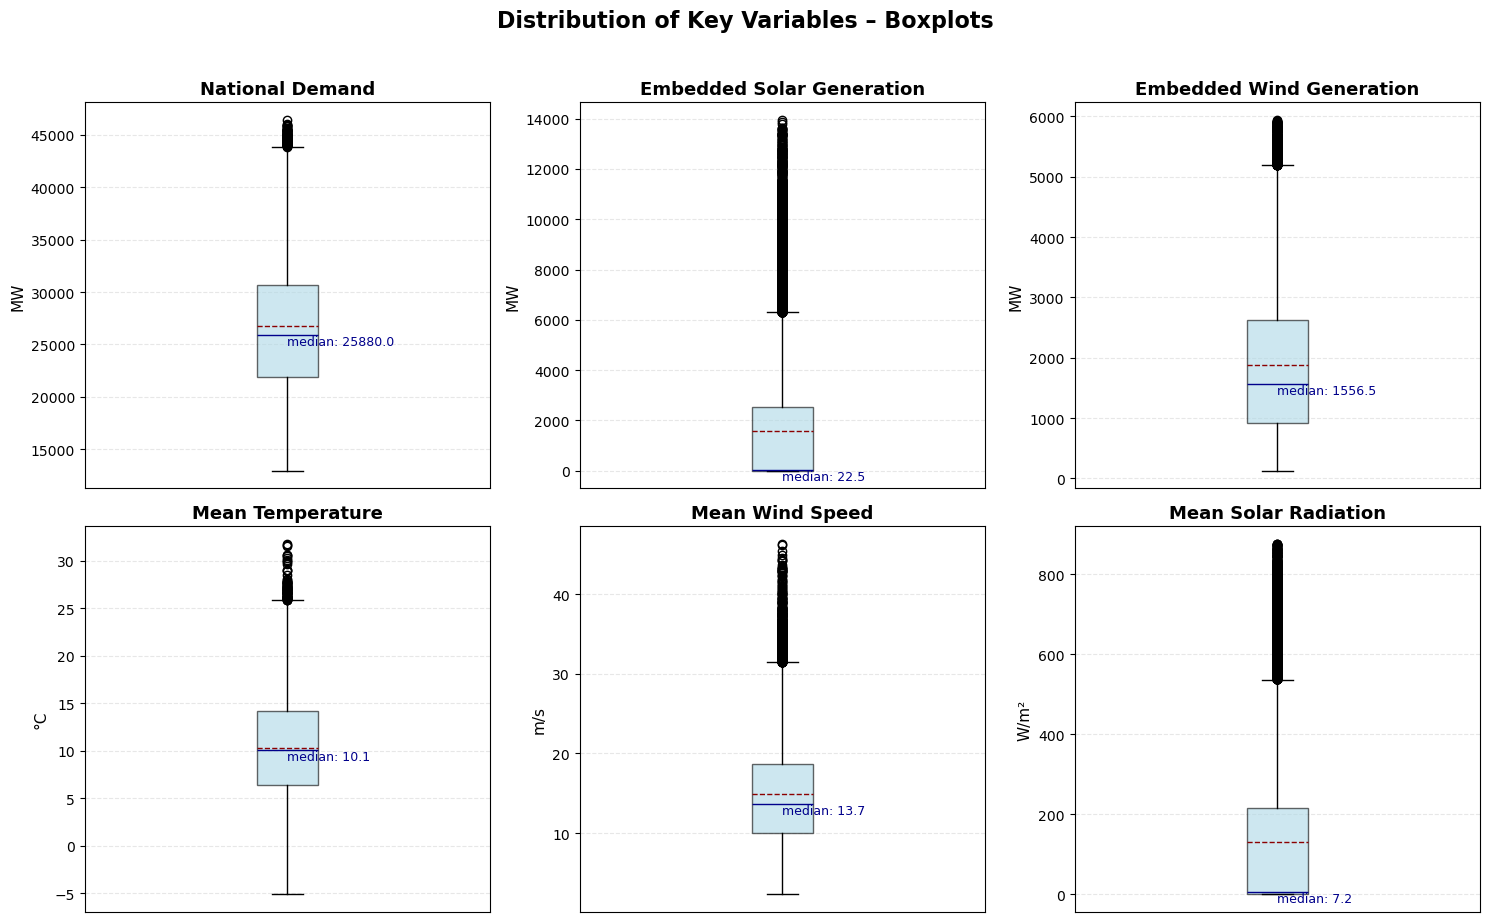

In [55]:
import matplotlib.pyplot as plt

# Define the variables and their nice labels + units
variables = {
    'ND':                       {'label': 'National Demand',             'unit': 'MW'},
    'EMBEDDED_SOLAR_GENERATION': {'label': 'Embedded Solar Generation',   'unit': 'MW'},
    'EMBEDDED_WIND_GENERATION':  {'label': 'Embedded Wind Generation',    'unit': 'MW'},
    'Temp_Mean':                {'label': 'Mean Temperature',            'unit': '°C'},
    'Wind_Mean':                {'label': 'Mean Wind Speed',             'unit': 'm/s'},
    'Solar_Mean':               {'label': 'Mean Solar Radiation',        'unit': 'W/m²'}
}

# Create figure with subplots – adjust rows/cols to your liking
n_vars = len(variables)
n_cols = 3  # you can change to 2 or 4
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4.5),
                         squeeze=False)  # squeeze=False → always 2D array

axes = axes.flatten()  # make it easy to iterate

for i, (var, info) in enumerate(variables.items()):
    ax = axes[i]
    
    # Create boxplot
    bp = ax.boxplot(df[var].dropna(), vert=True, patch_artist=True,
                    showmeans=True, meanline=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.6),
                    medianprops=dict(color='darkblue'),
                    meanprops=dict(color='darkred'))
    
    ax.set_title(info['label'], fontsize=13, fontweight='bold')
    ax.set_ylabel(info['unit'], fontsize=11)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Hide x-ticks (only one box per plot)
    ax.set_xticks([])
    
    # Optional: add median value text
    median_val = df[var].median()
    ax.text(1, median_val, f'median: {median_val:.1f}', 
            ha='left', va='top', fontsize=9, color='darkblue')

# Hide empty subplots if any
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Variables – Boxplots', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

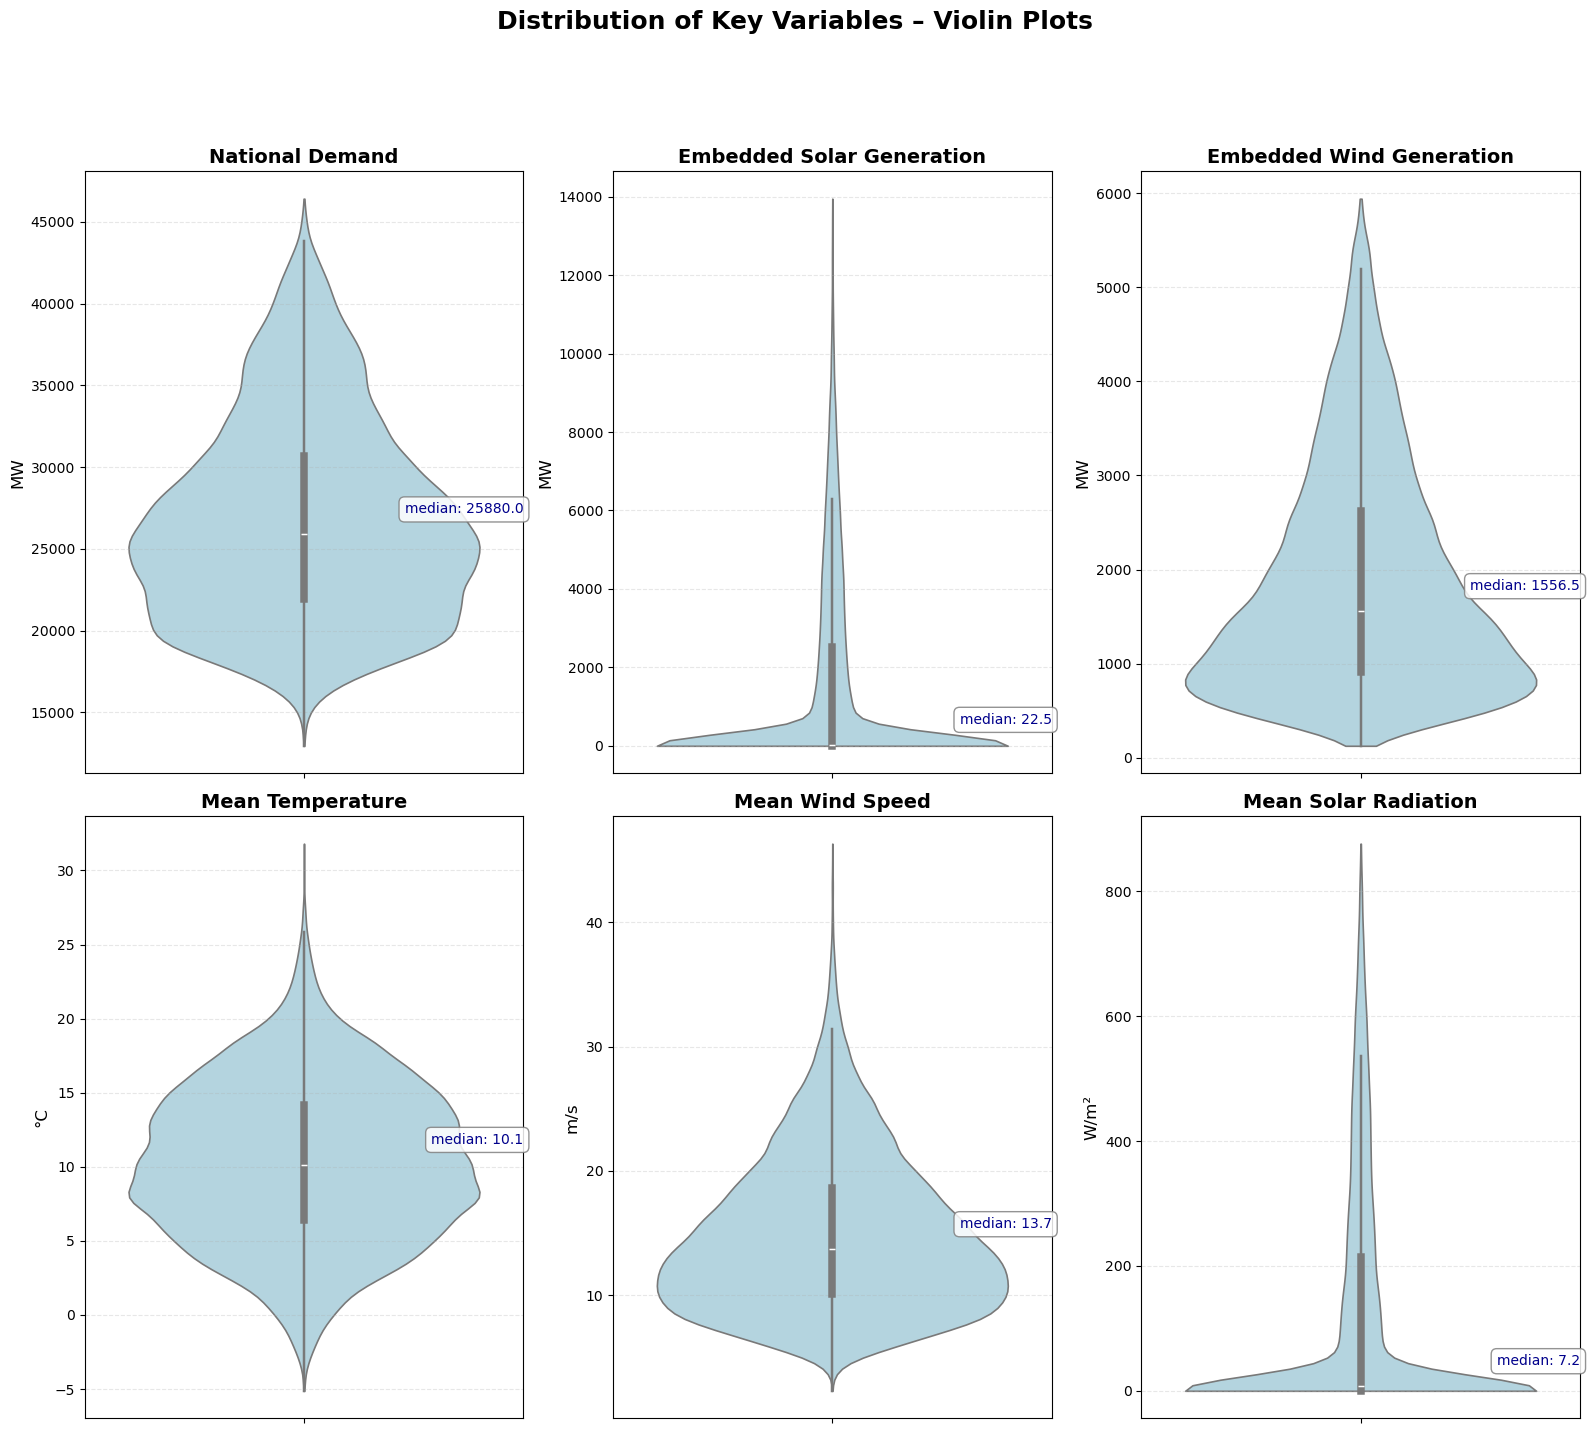

In [65]:
# Variables with titles and y-labels
variables = {
    'ND':                       {'title': 'National Demand',             'ylabel': 'MW'},
    'EMBEDDED_SOLAR_GENERATION': {'title': 'Embedded Solar Generation',   'ylabel': 'MW'},
    'EMBEDDED_WIND_GENERATION':  {'title': 'Embedded Wind Generation',    'ylabel': 'MW'},
    'Temp_Mean':                {'title': 'Mean Temperature',            'ylabel': '°C'},
    'Wind_Mean':                {'title': 'Mean Wind Speed',             'ylabel': 'm/s'},
    'Solar_Mean':               {'title': 'Mean Solar Radiation',        'ylabel': 'W/m²'}
}

fig, axes = plt.subplots(2, 3, figsize=(16, 14), squeeze=False)
axes = axes.flatten()

for i, (var_name, info) in enumerate(variables.items()):
    ax = axes[i]
    
    sns.violinplot(
        y=df[var_name],
        ax=ax,
        inner='box',
        color='lightblue',
        linewidth=1.2,
        cut=0
    )
    
    ax.set_title(info['title'], fontsize=14, fontweight='bold')
    ax.set_ylabel(info['ylabel'], fontsize=12)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Median label with offset and background box
    median_val = df[var_name].median()
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    offset = y_range * 0.03  # 3% above
    label_y = median_val + offset if median_val + offset < ax.get_ylim()[1] else median_val - offset
    
    ax.text(0.5, label_y, f'median: {median_val:.1f}',
            ha='right', va='bottom', fontsize=10, color='darkblue',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.4'))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Variables – Violin Plots', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()